# 0. Imports

In [ ]:
from importlib import reload

from flux_weighted_impact_parameters import make_impact_parameter_map, make_azimuthal_angle_map
from flux_weighted_impact_parameters import compute_kappa_shear_map_from_deflections, scale_lensing_matrix, compute_magnification_map_from_deflections as compute_magnification_from_lensing_matrices
from flux_weighted_impact_parameters import make_segmentation_map_and_mask, keep_sources_within_radius
from flux_weighted_impact_parameters import get_binned_pixel_stats
from flux_weighted_impact_parameters.rebinning import get_extent, get_extent_in_other_frame, downscale_highres_image, upsample_low_res_mask
from flux_weighted_impact_parameters.flux_contribution_maps import compute_arc_sky_flux_contributions
from flux_weighted_impact_parameters import (
    plot_HST_and_MUSE_cutouts,
    plot_HST_original_convolved_rebinned_and_mask,
    plot_spaxels_on_highres,
    plot_spaxels_on_lowres,
    plot_example_contribution_map_for_binned_pixel,
)

from flux_weighted_impact_parameters import make_summary_table_spaxels

from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
from astropy.stats import sigma_clipped_stats


from mpdaf.obj import Image


import matplotlib.pyplot as plt


import numpy as np


from scipy.ndimage import binary_dilation

# 1. Initial parameter definition

In [34]:

# Image to use
HST_filename = 'data/f606w.fits'

# Coordinates for cutout
RA_CENTER, DEC_CENTER = 186.7137862, 21.8715231
cutout_size =20 # arcsec
MUSE_binning_factor = 4
MUSE_native_pixscale = 0.2 # arcsec/pix


PSF_MUSE = 0.8 # arcsec
PSF_HST = 0.112 # arcsec

# G1 properties
ra_G1, dec_G1 = 186.7137917, 21.8714500 # original
PA_G1 = 68 #deg measured east of north 


# Lensing parameters
z_norm_matrices = 2.9233
z_lens = 0.43
z_source = 0.77
alpha_x_filename_arc = f"data/dplx_{z_norm_matrices}.fits"
alpha_y_filename_arc = f"data/dply_{z_norm_matrices}.fits"
alpha_x_filename = f"data/dplx_{z_source}.fits"
alpha_y_filename = f"data/dply_{z_source}.fits"
mangnification_filename = f"data/SGASJ1226_magnific_z{z_source}.fits"
output_path = f"data/simulation_z_{z_source}"

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# 2. Extract a cutout from the HST image and plot it

Opening high resolution image...


Plotting cutout...


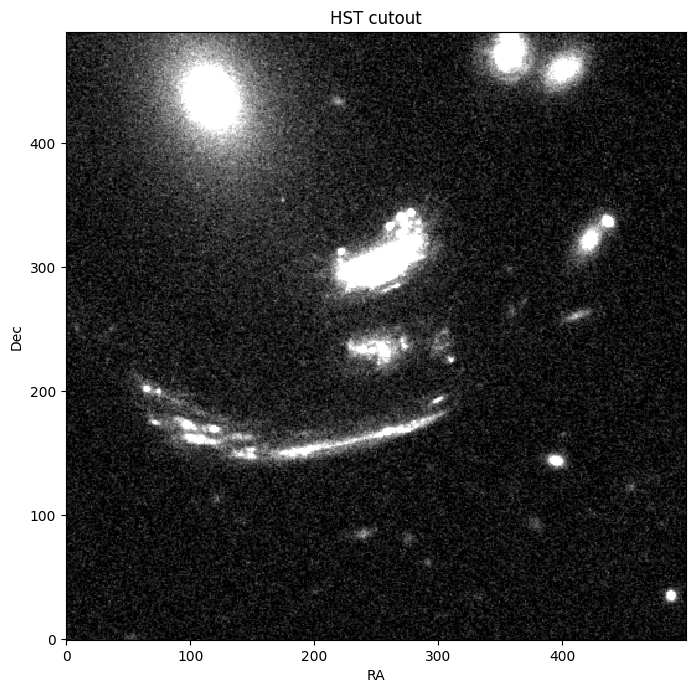

In [ ]:
# ============== Open high resolution image ==============
print("Opening high resolution image...")
# image filename
hst_image = Image(HST_filename, ext=1)
mean, median, std = sigma_clipped_stats(hst_image.data, sigma=3)
hst_image.data -= median
hst_pixscale = hst_image.wcs.wcs.proj_plane_pixel_scales()[0].to_value(u.arcsec)

hst_cutout = hst_image.subimage(center=(DEC_CENTER, RA_CENTER), size=cutout_size,
                                    unit_center=u.deg, unit_size=u.arcsec)[10:, :]


# ============== Plot the cutout ==============
print("Plotting cutout...")
mean, median, std = sigma_clipped_stats(hst_cutout.data, sigma=3)
fig, ax = plt.subplots(figsize=(8, 8))
hst_cutout.plot(ax=ax, cmap='gray', vmin=median-std, vmax=median+10*std)
ax.set_title("HST cutout")
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()
fig.savefig("plots/HST_cutout.png", dpi=300)

# 3. Convolve the HST image to match the PSF of a MUSE observation

Plotting cutout...


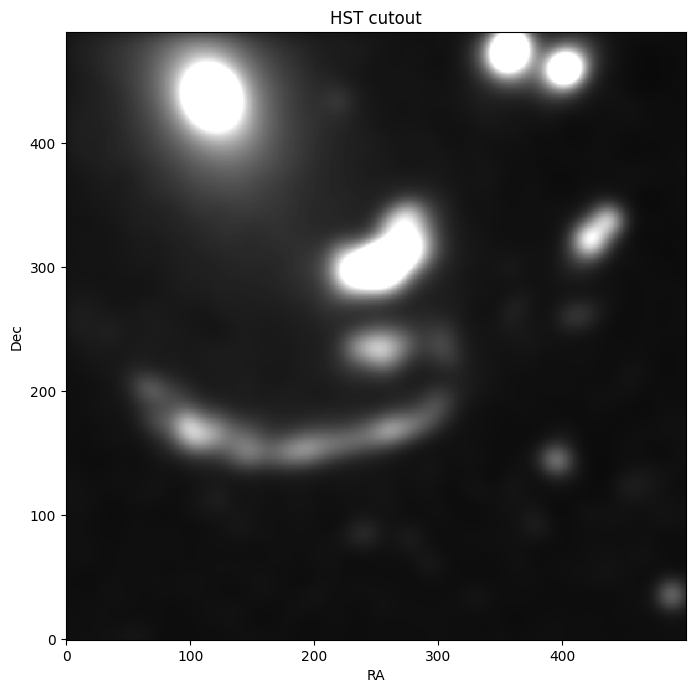

In [ ]:
# ============== Now cut highres image to match MUSE ==============
psf_kernel_FWHM = np.sqrt(PSF_MUSE**2 - PSF_HST**2)
psf_kernel_pix = psf_kernel_FWHM  / hst_pixscale
hst_convolved = hst_cutout.fftconvolve_gauss(fwhm=(psf_kernel_pix, psf_kernel_pix), unit_fwhm=None)

print("Plotting cutout...")
mean, median, std = sigma_clipped_stats(hst_cutout.data, sigma=3)
fig, ax = plt.subplots(figsize=(8, 8))
hst_convolved.plot(ax=ax, cmap='gray', vmin=median-std, vmax=median+10*std)
ax.set_title("HST cutout")
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
plt.show()
fig.savefig("plots/HST_convolved.png", dpi=300)


# 4. Now make a segmentation image to select the gravitational arc regions

Segmentation labels and have to be selected iteratively to select only arc images

Making segmentation map and mask...


/data/estudiantes/jhernandez/anaconda3/envs/stenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/data/estudiantes/jhernandez/anaconda3/envs/stenv/lib/python3.9/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/data/estudiantes/jhernandez/anaconda3/envs/stenv/lib/python3.9/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Plotting HST image, segmentation map, and mask together...


Text(0.5, 1.0, 'Mask')

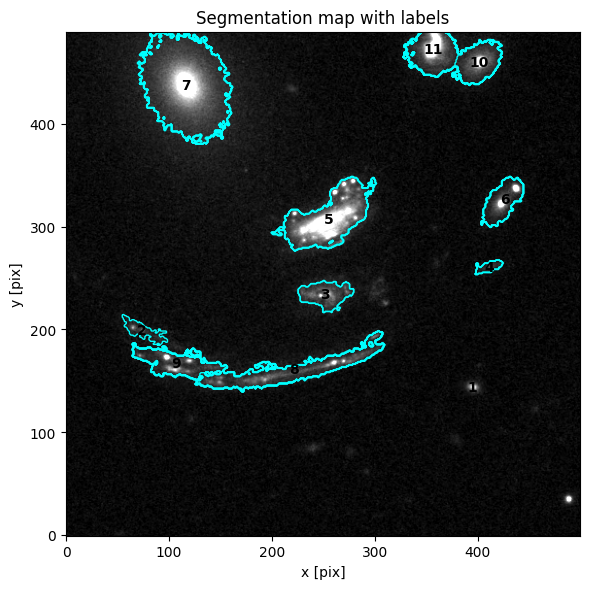

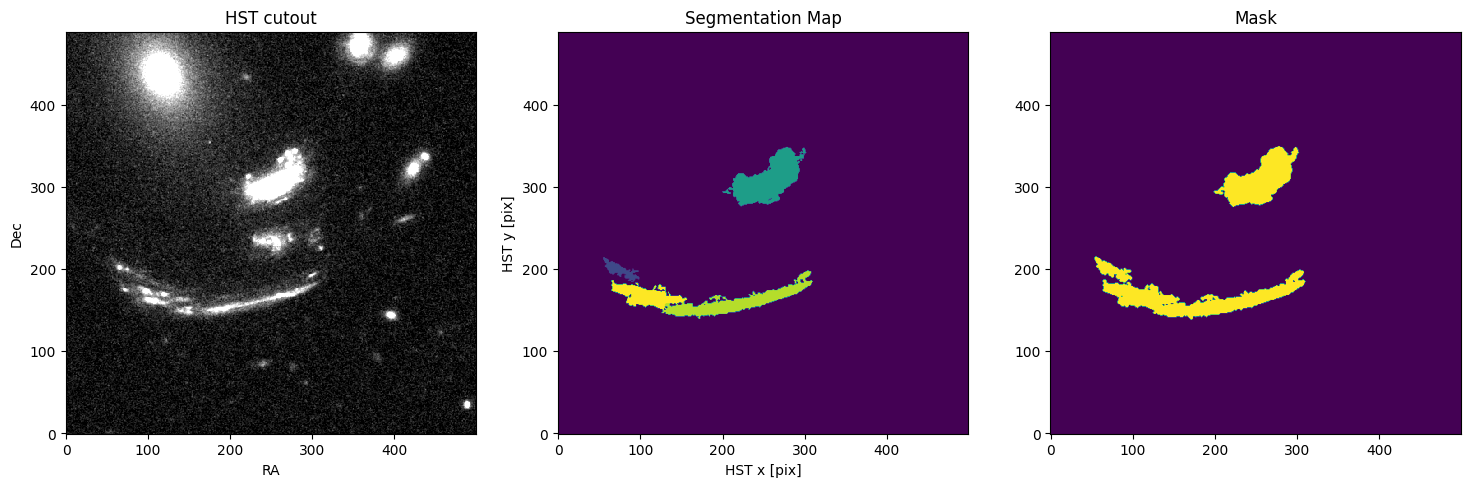

In [ ]:

# ============= Make segmentation map and mask ==============
print("Making segmentation map and mask...")
segm, catalog, mask_arc = make_segmentation_map_and_mask(hst_cutout, 
                                                        interactive=False, labels=[9, 8,
                                                                                    5,
                                                                                    2], npixels=200)# binnay dilate the mask to ensure we are masking the sources and their immediate surroundings
mask_arc = binary_dilation(mask_arc.astype(bool).astype(int), iterations=1)



# plot hst image, segmentation map, and mask together
print("Plotting HST image, segmentation map, and mask together...")
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(18, 6))  
mean, median, std = sigma_clipped_stats(hst_cutout.data, sigma=3)
hst_cutout.plot(ax=axs[0], cmap='gray', vmin=median-std, vmax=median+10*std)
axs[0].set_title("HST cutout")
axs[0].set_xlabel("RA")
axs[0].set_ylabel("Dec")
axs[1].imshow(segm, origin='lower')
axs[1].set_title('Segmentation Map')
axs[1].set_xlabel('HST x [pix]')
axs[1].set_ylabel('HST y [pix]')
axs[2].imshow(mask_arc, origin='lower')
axs[2].set_title('Mask')            
fig.tight_layout()
fig.savefig("plots/HST_cutout_segmentation_mask.png")

# 5. Make the low resoltuion mask and rebin the high resolution convolved image

Rebinning HST data and masks...
Plotting rebinned HST image and rebinned mask together...


Text(0, 0.5, 'HST y [rebinned pix]')

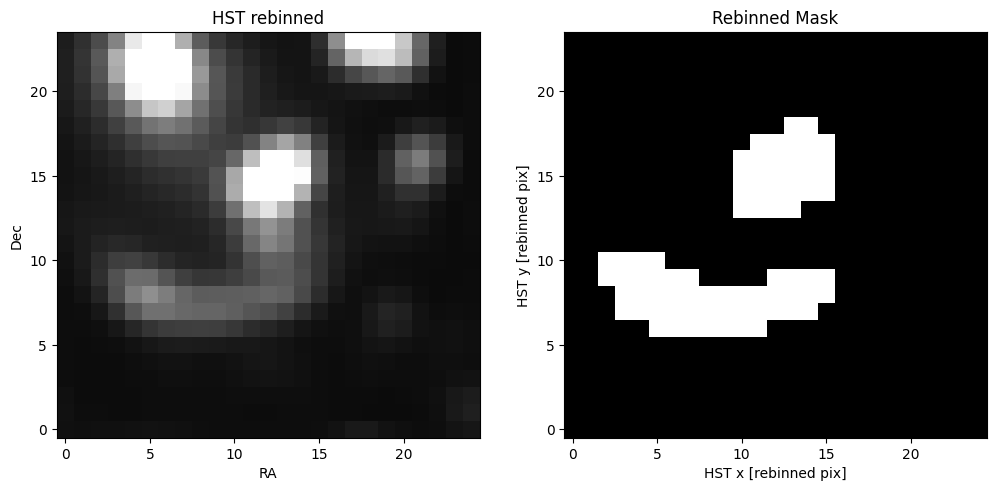

In [ ]:
# ============== bin HST data and masks
print("Rebinning HST data and masks...")
rebin_factor = MUSE_native_pixscale / hst_pixscale

hst_rebinned = downscale_highres_image(hst_convolved, target_pixscale_arcsec=MUSE_native_pixscale*MUSE_binning_factor)
hst_rebinned.write("data/hst_rebinned.fits")
mask_arc_image = Image(data=mask_arc.astype(float), wcs=hst_cutout.wcs)


flux_fraction_dict = compute_arc_sky_flux_contributions(hst_cutout, mask_arc,
                                                             MUSE_binning_factor*MUSE_native_pixscale, PSF_MUSE)
mask_rebinned = hst_rebinned.copy()
mask_rebinned.data = ((flux_fraction_dict['arc_flux_fraction'] > 0.5)&(flux_fraction_dict['snr'] > 1) ).astype(int)

# plot the rebinned image and mask together
print("Plotting rebinned HST image and rebinned mask together...")
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))  
mean, median, std = sigma_clipped_stats(hst_rebinned.data, sigma=3)
hst_rebinned.plot(ax=axs[0], cmap='gray', vmin=median-std, vmax=median+10*std)
axs[0].set_title("HST rebinned")
axs[0].set_xlabel("RA")
axs[0].set_ylabel("Dec")
axs[1].imshow(mask_rebinned.data, origin='lower', cmap='gray')
axs[1].set_title('Rebinned Mask')
axs[1].set_xlabel('HST x [rebinned pix]')
axs[1].set_ylabel('HST y [rebinned pix]')   

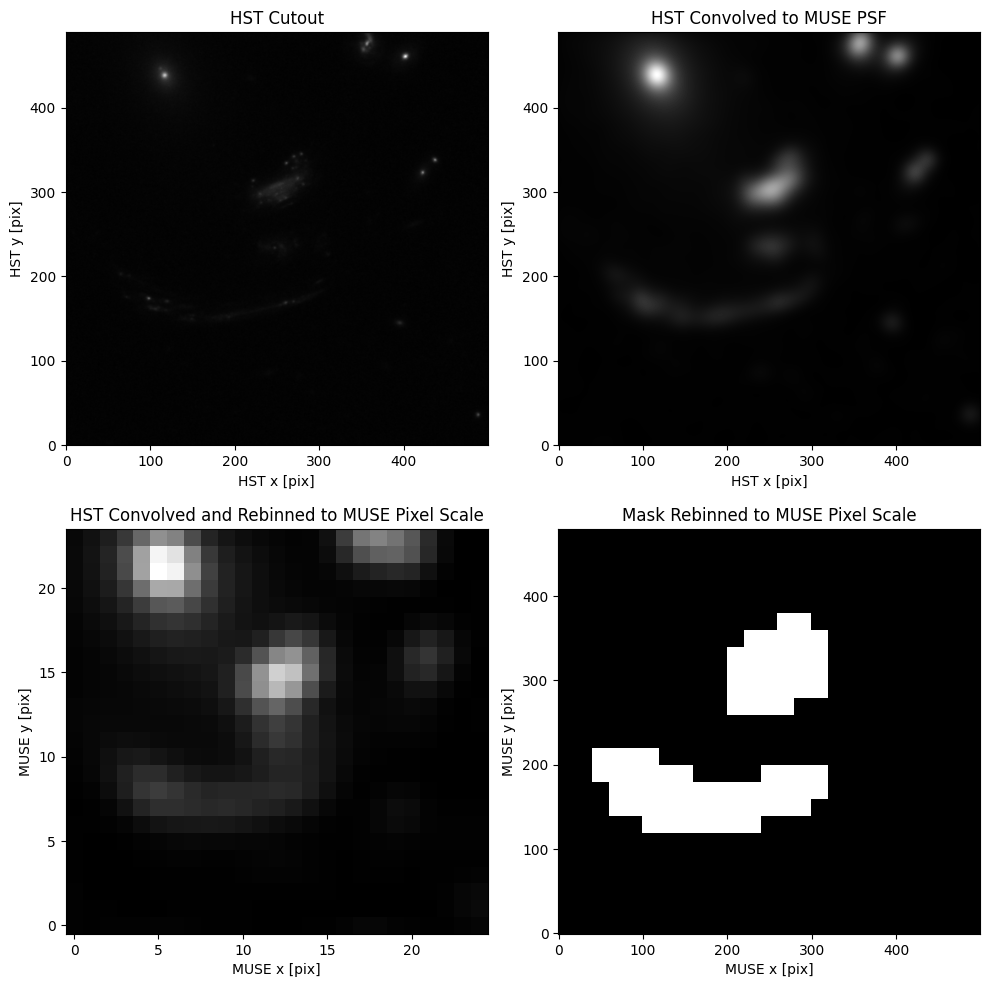

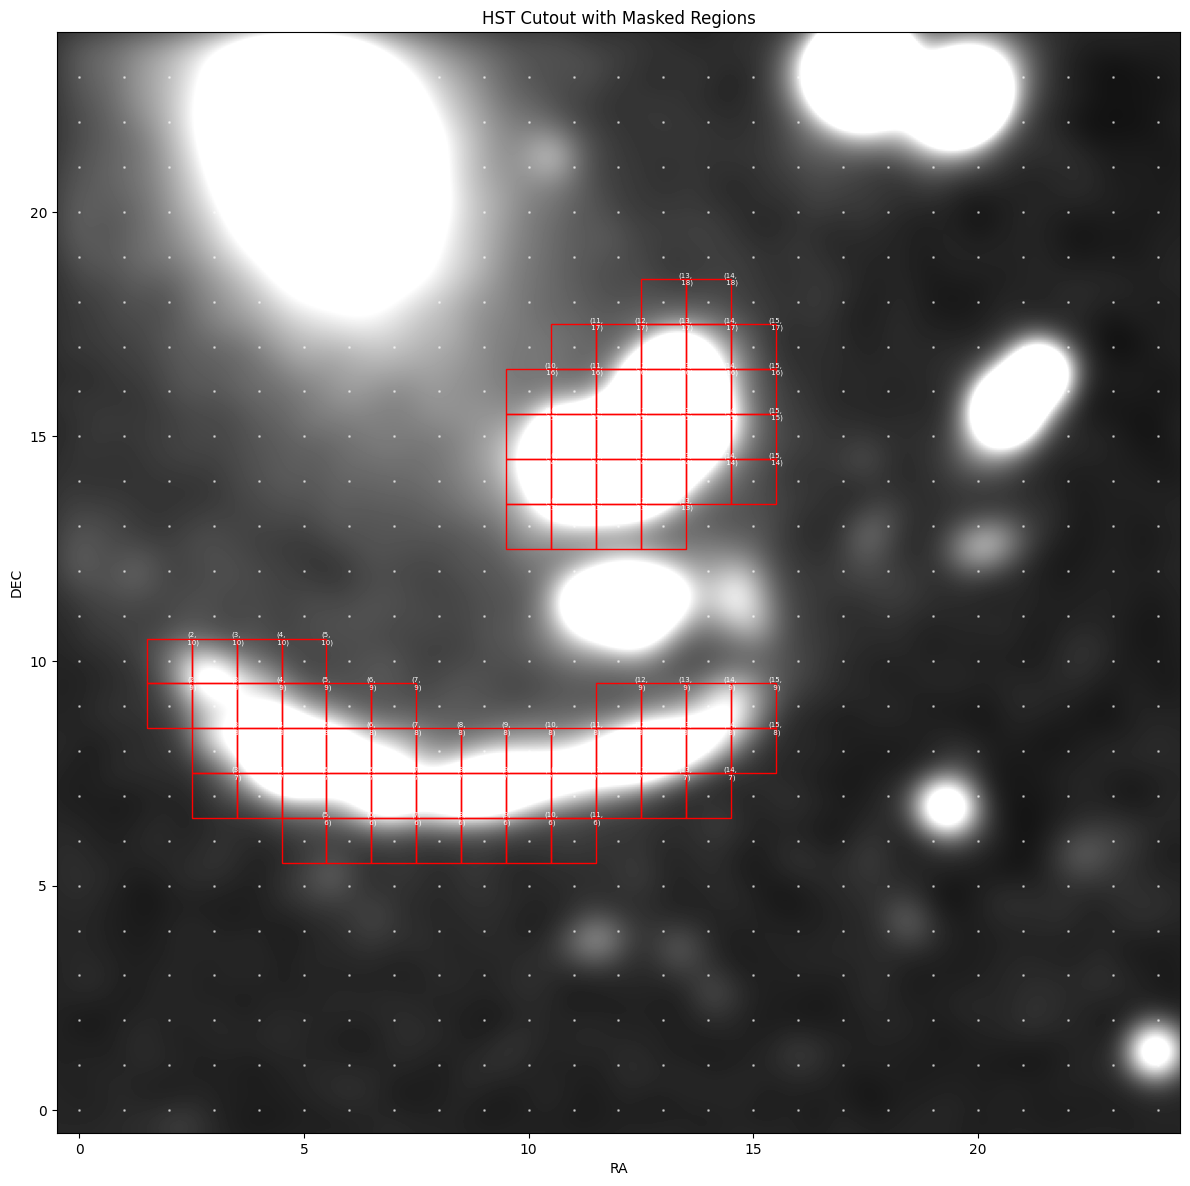

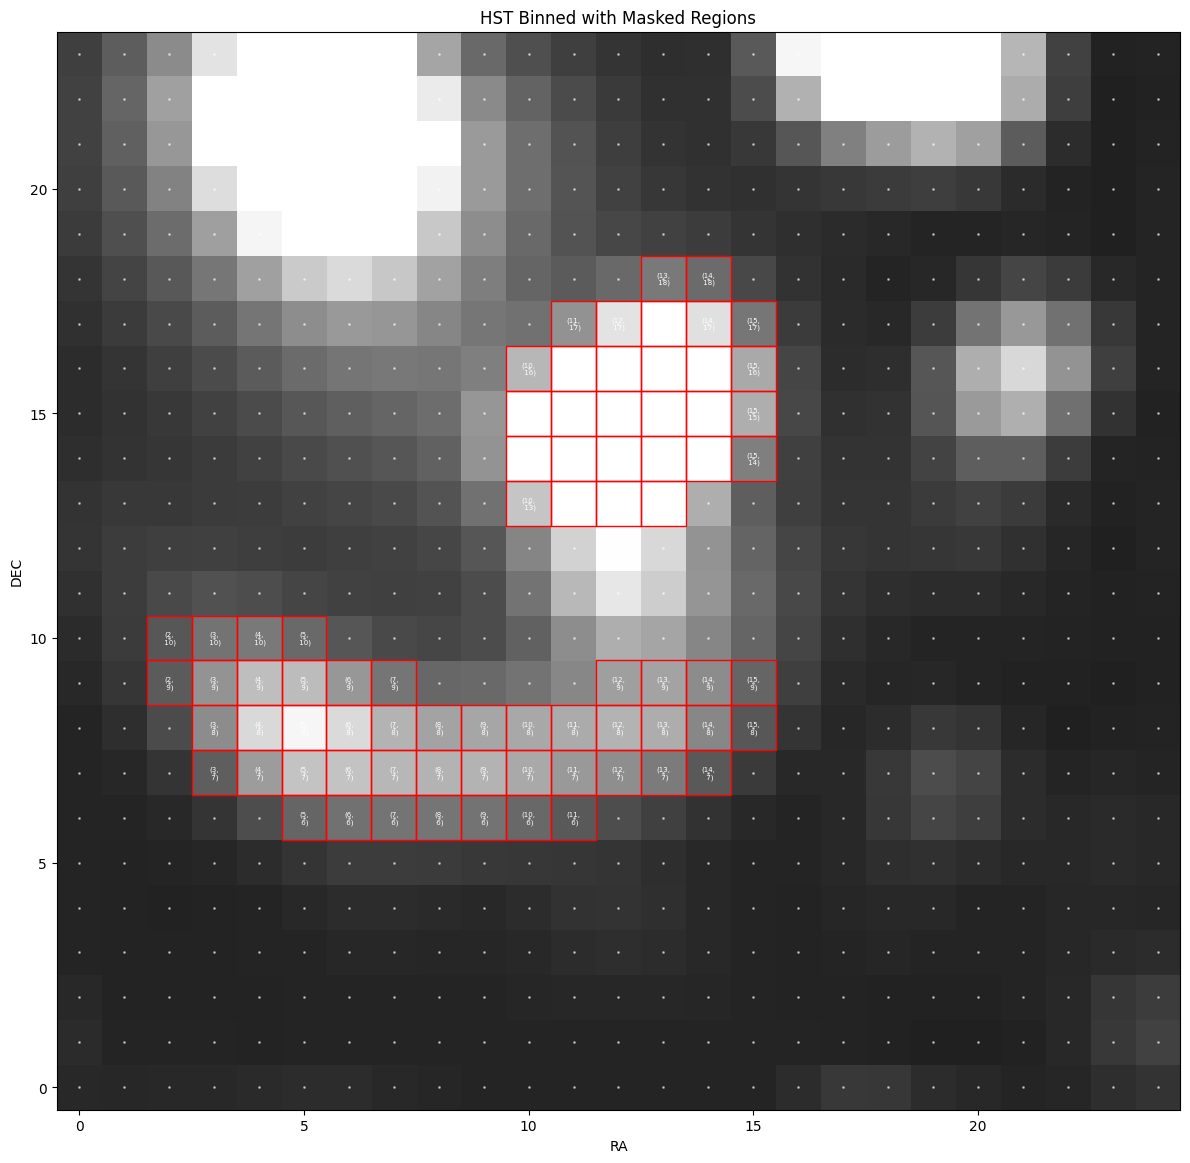

In [18]:
plot_HST_original_convolved_rebinned_and_mask(hst_cutout, hst_convolved, hst_rebinned, mask_rebinned, out_filename="plots/HST_convolved_rebinned_mask.png")
plot_spaxels_on_highres(hst_convolved, mask_rebinned, filename="plots/HST_cutout_with_masked_spaxels.png")
plot_spaxels_on_lowres(hst_rebinned, mask_rebinned, filename="plots/HST_rebinned_with_masked_spaxels.png")


# Scale lensing matrices

In [ ]:
# ============= scale lensing matrices and compute magnification ==============
print("Scaling lensing matrices and computing magnification map...")
scale_lensing_matrix(alpha_x_filename_arc, z_lens, z_source, z_norm_matrices, alpha_x_filename)
scale_lensing_matrix(alpha_y_filename_arc, z_lens, z_source, z_norm_matrices, alpha_y_filename)
# set header key BUNIT to 'arcsec'
fits.setval(f"{alpha_x_filename}", "BUNIT", value="arcsec")
fits.setval(f"{alpha_y_filename}", "BUNIT", value="arcsec")

alpha_x = Image(alpha_x_filename)
alpha_y = Image(alpha_y_filename)

mu_image = compute_magnification_from_lensing_matrices(alpha_x, alpha_y, )
gamma, gamma1, gamma2, kappa = compute_kappa_shear_map_from_deflections(alpha_x, alpha_y)
gamma = gamma.align_with_image(hst_cutout, flux=False)
gamma1 = gamma1.align_with_image(hst_cutout, flux=False)
gamma2 = gamma2.align_with_image(hst_cutout, flux=False)
kappa = kappa.align_with_image(hst_cutout, flux=False)
gamma.write("data/shear_map.fits")
gamma1.write("data/shear1_map.fits")
gamma2.write("data/shear2_map.fits")
kappa.write("data/kappa_map.fits")
mu_image.write("data/magnification_map.fits")


Scaling lensing matrices and computing magnification map...


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


# Calculate impact parameter maps

Calculating impact parameter and azimuthal angle maps...
Saved: data/impact_parameter_map_hst_f606w.fits
Map shape: (490, 500)
Impact parameter range: 0.032 - 84.771 kpc
G1 source-plane position: RA=186.7143835, Dec=21.8686419


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


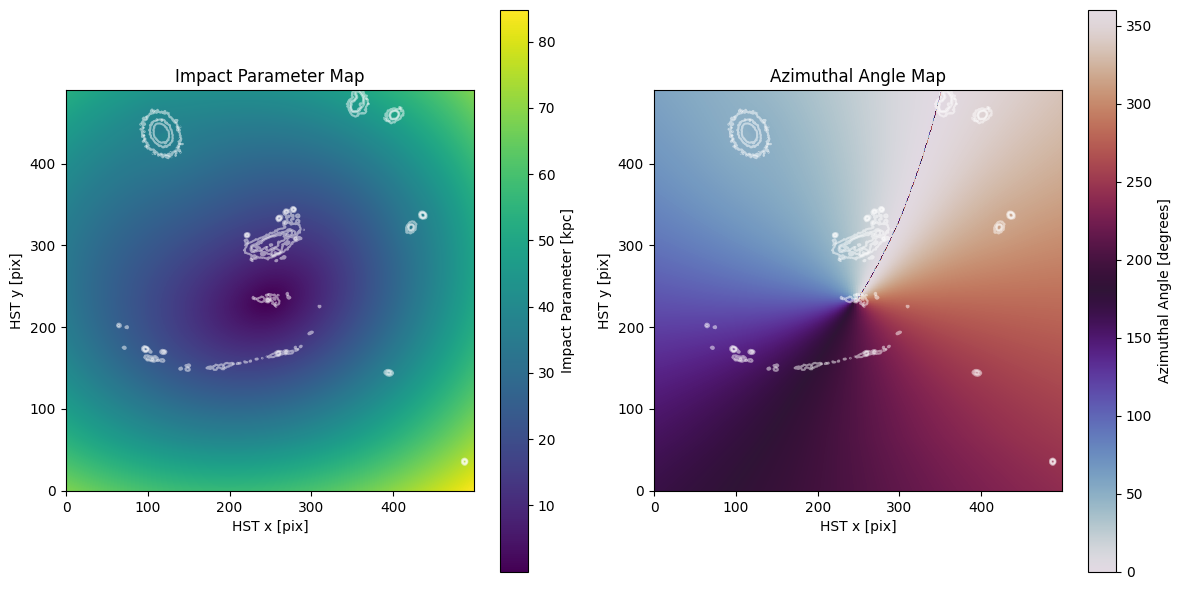

In [25]:
# ==============  Calculate impact parameter and azimuthal angle maps ==============
print("Calculating impact parameter and azimuthal angle maps...")
# Calculate the impact parameter map and azimuthal angle map
output_fits = "data/impact_parameter_map_hst_f606w.fits"
output_az_map = "data/azimuthal_angle_map_hst_f606w.fits"


make_impact_parameter_map(
    hst_cutout,
    dir_matrices='.',
    alpha_x_filename=alpha_x_filename,
    alpha_y_filename=alpha_y_filename,
    ra_G=ra_G1,
    dec_G=dec_G1,
    z_G=z_source,
    cosmo=cosmo,
    output_fits=output_fits)

make_azimuthal_angle_map(
    hst_cutout,
    dir_matrices='.',
    alpha_x_filename=alpha_x_filename,
    alpha_y_filename=alpha_y_filename,
    ra_G=ra_G1,
    dec_G=dec_G1,
    PA_G=PA_G1,
    z_G=z_source,
    cosmo=cosmo,
    output_fits=output_az_map)

impact_parameter_map = Image(output_fits)
az_angle_map = Image(output_az_map)

mu_aligned = mu_image.align_with_image(hst_cutout, flux=False)


# plot azimuthal angle and impact parameters maps together and overlay hst contours
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))
im0 = axs[0].imshow(impact_parameter_map.data, origin='lower', cmap='viridis')
axs[0].set_title('Impact Parameter Map')
axs[0].set_xlabel('HST x [pix]')
axs[0].set_ylabel('HST y [pix]')
plt.colorbar(im0, ax=axs[0], label='Impact Parameter [kpc]')
mean, median, std = sigma_clipped_stats(hst_cutout.data, sigma=3)
axs[0].contour(hst_cutout.data, levels=[10*std, 20*std, 30*std], colors='white', alpha=0.5)

im1 = axs[1].imshow(az_angle_map.data, origin='lower', cmap='twilight', vmin=0, vmax=360)
axs[1].set_title('Azimuthal Angle Map')
axs[1].set_xlabel('HST x [pix]')
axs[1].set_ylabel('HST y [pix]')
plt.colorbar(im1, ax=axs[1], label='Azimuthal Angle [degrees]')
mean, median, std = sigma_clipped_stats(hst_cutout.data, sigma=3)
axs[1].contour(hst_cutout.data, levels=[10*std, 20*std, 30*std], colors='white', alpha=0.5)
fig.tight_layout()
fig.savefig("plots/impact_parameter_and_azimuthal_angle_maps.png", dpi=300)

# Calculate pixel stats

In [26]:
# ======== Calculate Pixel Stats ==========\
print("Calculating pixel stats for each binned pixel...")
binned_pixel_stats = get_binned_pixel_stats(hst_cutout, mask_arc,
    hst_rebinned, mask_rebinned, PSF_HST, PSF_MUSE, mu_aligned,
    impact_parameter_map, az_angle_map, gamma1, gamma2, kappa,
    binfactor=MUSE_binning_factor)

spaxels_table = make_summary_table_spaxels(binned_pixel_stats)
spaxels_table.write("outputs/spaxels_summary_table.fits", overwrite=True)

Calculating pixel stats for each binned pixel...
Processing pixel (x=5, y=6)...
Processing pixel (x=6, y=6)...
Processing pixel (x=7, y=6)...
Processing pixel (x=8, y=6)...
Processing pixel (x=9, y=6)...
Processing pixel (x=10, y=6)...
Processing pixel (x=11, y=6)...
Processing pixel (x=3, y=7)...
Processing pixel (x=4, y=7)...
Processing pixel (x=5, y=7)...
Processing pixel (x=6, y=7)...
Processing pixel (x=7, y=7)...
Processing pixel (x=8, y=7)...
Processing pixel (x=9, y=7)...
Processing pixel (x=10, y=7)...
Processing pixel (x=11, y=7)...
Processing pixel (x=12, y=7)...
Processing pixel (x=13, y=7)...
Processing pixel (x=14, y=7)...
Processing pixel (x=3, y=8)...
Processing pixel (x=4, y=8)...
Processing pixel (x=5, y=8)...
Processing pixel (x=6, y=8)...
Processing pixel (x=7, y=8)...
Processing pixel (x=8, y=8)...
Processing pixel (x=9, y=8)...
Processing pixel (x=10, y=8)...
Processing pixel (x=11, y=8)...
Processing pixel (x=12, y=8)...
Processing pixel (x=13, y=8)...
Processing

/data/estudiantes/jhernandez/anaconda3/envs/stenv/lib/python3.9/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


(<Figure size 1600x600 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Impact Parameter [kpc]', ylabel='Weighted PDF'>],
       dtype=object))

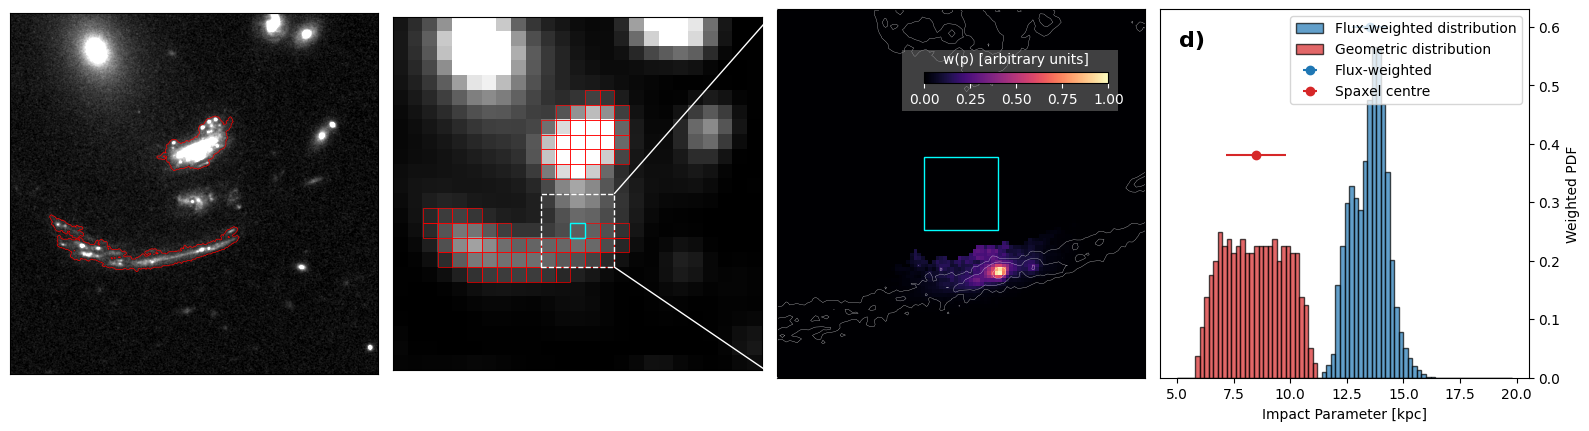

In [27]:
# force reimport
import importlib
importlib.reload(flux_weighted_impact_parameters)
importlib.reload(flux_weighted_impact_parameters.plot_utils)
from flux_weighted_impact_parameters import plot_hst_binned_pixels_contribution_map_and_impact_parameter_distribution  


plot_hst_binned_pixels_contribution_map_and_impact_parameter_distribution(x_bin=12, y_bin=9, binned_pixel_stats=binned_pixel_stats,
                                                                        hst_rebinned=hst_rebinned,
                                                                        hst_cutout=hst_cutout, mask_arc_highres=mask_arc,
                                                                        out_filename="example_contribution_map.png",
                                                                        min_impact_parameter=5, max_impact_parameter=20, delta_bin=0.5)
                                                                          

/data/estudiantes/jhernandez/Software/flux-weighted-impact-parameters/src/flux_weighted_impact_parameters/plot_utils.py:447: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  


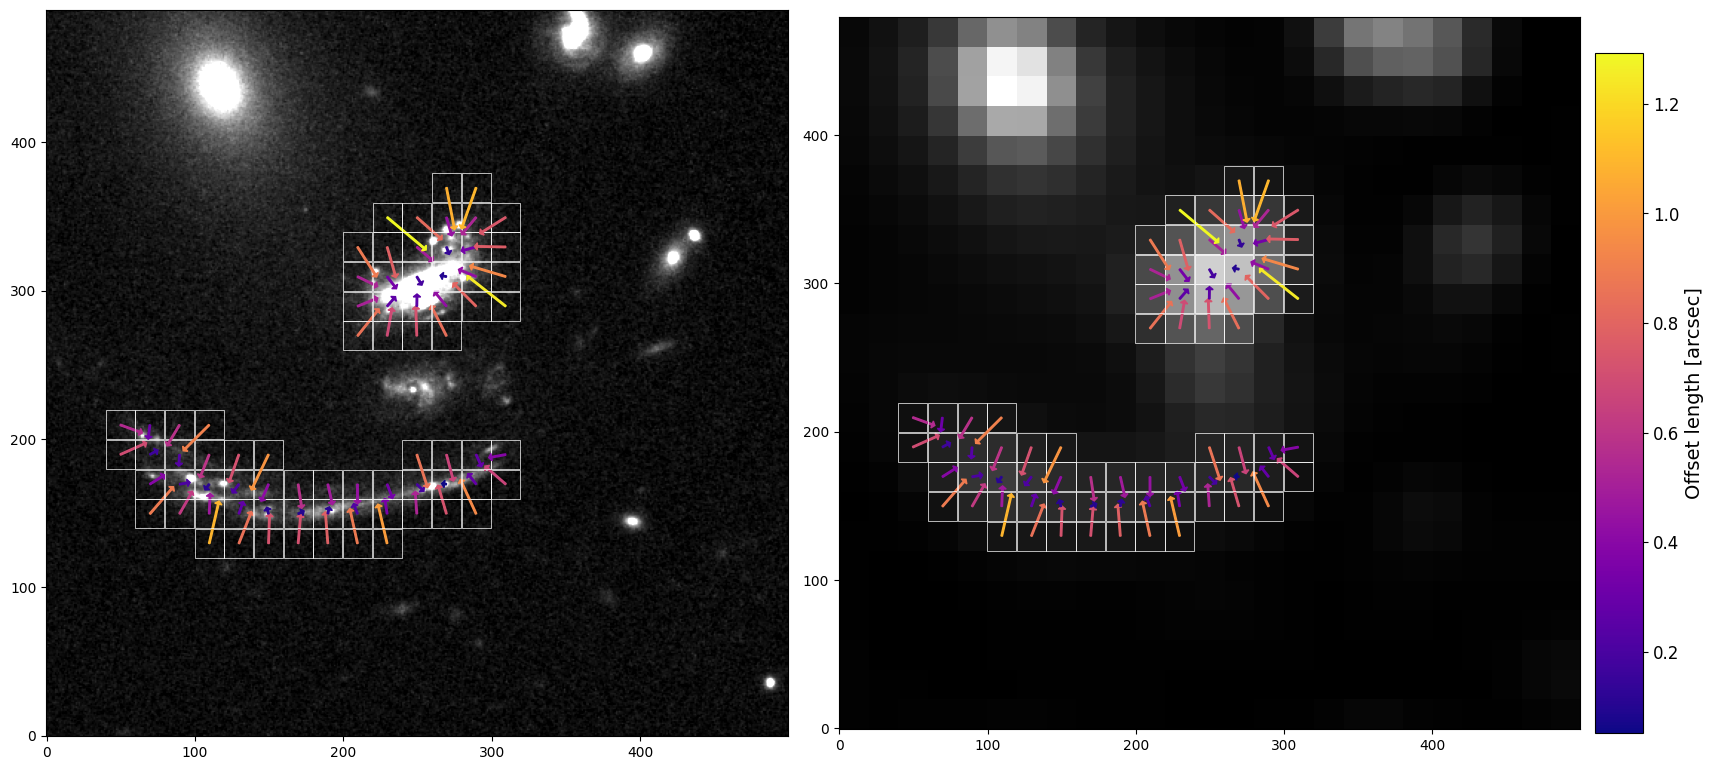

In [31]:
import importlib
importlib.reload(flux_weighted_impact_parameters)
importlib.reload(flux_weighted_impact_parameters.plot_utils)
from flux_weighted_impact_parameters import plot_displacement_maps

plot_displacement_maps(binned_pixel_stats, hst_cutout, hst_rebinned, out_filename="plots/displacement_maps.pdf")